# TP1 — From Theory to Practice: MLP with PyTorch

---

## Objectives

By the end of this session, you will be able to:
1. Manipulate **PyTorch tensors and automatic differentiation** as the computational substrate of deep learning
2. Implement a **complete supervised training pipeline** from data loading to evaluation
3. Design and interpret **controlled experiments** comparing optimisation strategies and regularisation techniques

## Prerequisites (CM1–CM2)
- **CM1**: MLP architecture, activation functions, backpropagation, vanishing/exploding gradients
- **CM2**: PyTorch training pipeline — DataLoader, nn.Module, optimisers, Dropout, Batch Normalisation

## Deliverables
**Send your GitHub repository link to [xchang3@slb.com](mailto:xchang3@slb.com) and submit on GitHub before the deadline.**
```
your-repo/
├── tp1-pytorch-mlp.ipynb   ← all cells executed top-to-bottom, outputs visible
└── report.pdf              ← 1–2 pages, maximum 2 pages
```

**Deadline**: **23:59, September 24th**

This TP is completed in pairs. Submit one GitHub repository per pair.

Your PDF report should answer the following sections:
1. **Part 1 — Baseline Model**: answer the four questions at the end of Part 1
2. **Experiment 1**: fill in the Results and Analysis section
3. **Experiment 2A**: fill in the Results and Analysis section
4. **Experiment 2B**: fill in the Results and Analysis section
5. **Experiment 3**: fill in the Results and Analysis section

Results must be discussed analytically — cite specific numbers, reference figures by their titles, and connect observations to theory from CM1/CM2.

## Session Structure

| Part | Content |
|------|---------|
| 0 · Tensor Warmup | Core tensor operations and automatic differentiation |
| 1 · Training Pipeline | End-to-end MLP implementation on Fashion-MNIST |
| 2 · Experimental Analysis | Student-designed ablation studies |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ── Device setup ──────────────────────────────────────────────────────────────
# PyTorch uses the "cuda" API for both NVIDIA CUDA and AMD ROCm.
if torch.cuda.is_available():
    device = torch.device('cuda')
    backend = 'ROCm' if torch.version.hip is not None else 'CUDA'
else:
    device = torch.device('cpu')
    backend = 'CPU'

print(f'Using device: {device} ({backend})')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(device)}')
    if backend == 'ROCm':
        print(f'HIP version: {torch.version.hip}')
    else:
        print(f'CUDA version: {torch.version.cuda}')
print(f'PyTorch version: {torch.__version__}')

# num_workers: multiprocessing helps on GPU; set to 0 on CPU to avoid fork issues
NUM_WORKERS = 2 if device.type == 'cuda' else 0


Using device: cuda (ROCm)
GPU: AMD Radeon RX 7900 XT
HIP version: 7.14.60850
PyTorch version: 2.14.0+rocm7.14


---
## Part 0 — Tensor Warmup

This section introduces PyTorch's core primitives — tensors and automatic differentiation — which underpin every operation in a deep learning pipeline.

### Exercise 0.1 — Tensor Operations

A neural network forward pass is a composition of matrix multiplications and element-wise non-linearities. The following exercise traces one such step explicitly in PyTorch. Complete the `# TODO` sections.

In [ ]:
# (a) A mini-batch of 4 28×28 images, each flattened to 784 pixels
batch = torch.zeros(4, 784)
print(f'Batch shape: {batch.shape}')

# (b) Weight matrix for a Linear layer: 784 inputs → 128 outputs
# TODO: Create a random weight matrix W using torch.randn with the correct shape, shape: (out_features, in_features)
W = torch.randn(128, 784)

# (c) Linear transformation (4, 784) * (784, 128) → (4, 128)
# TODO: Compute the matrix product — result should have shape [4, 128]
output = batch @ W.T
if output is not None:
    print(f'Linear output shape: {output.shape}')  # Expected: torch.Size([4, 128])

# (d) Apply ReLU activation  (recall CM1: why ReLU instead of Sigmoid?)
# TODO: Apply F.relu() to output
activated = F.relu(output)
if activated is not None:
    print(f'After ReLU — min value : {activated.min():.3f}')  # Must be 0.0
    print(f'           — #negatives: {(activated < 0).sum().item()}')  # Must be 0

Batch shape: torch.Size([4, 784])
Linear output shape: torch.Size([4, 128])
After ReLU — min value : 0.000
           — #negatives: 0


### Exercise 0.2 — Automatic Differentiation

PyTorch implements reverse-mode automatic differentiation through a dynamically constructed computation graph. This mirrors the backpropagation derivation, but is executed automatically by the framework.

**Before running the following cell**, derive $\frac{dL}{dw}$ analytically:

$$L = (wx - y)^2, \quad x = 2,\; y = 3,\; w = 1$$

$$\frac{dL}{dw} = 2(wx - y) \cdot x = ?$$

Record your result, then verify against PyTorch's computed gradient.

Complete the `# TODO` sections.

In [ ]:
x = torch.tensor(2.0)
y = torch.tensor(3.0)
w = torch.tensor(1.0, requires_grad=True)  # requires_grad=True: PyTorch will track this

my_gradient = 2 * (w * x - y) * x  # d/dw[(w*x - y)^2] = 2(w*x - y) * x
if my_gradient is not None:
    print(f'My manual dL/dw: {my_gradient}')

# x, y, and w must be PyTorch tensors for automatic differentiation to track the computation.

My manual dL/dw: -4.0


In [4]:
# PyTorch computes the gradient via reverse-mode autodiff
# call loss.backward() to trigger the backward pass
loss = (w * x - y) ** 2
loss.backward()
print(f'Analytical dL/dw:  {my_gradient}')
print(f'PyTorch  dL/dw:    {w.grad.item():.1f}')

# One gradient-descent update (lr = 0.1)
# TODO: compute new_w = w - lr * gradient  (use w.grad, lr = 0.1)
new_w = w.detach() - 0.1 * w.grad
print(f'Gradient step (lr=0.1): w = {w.item():.1f} -> {new_w:.2f}')
print(f'Updated prediction: {new_w * x.item():.2f}   (target: {y.item():.1f})')

Analytical dL/dw:  -4.0
PyTorch  dL/dw:    -4.0
Gradient step (lr=0.1): w = 1.0 -> 1.40
Updated prediction: 2.80   (target: 3.0)


---
## Part 1 — Training Pipeline

In this section, we will implement manually a complete MLP training pipeline step by step on Fashion-MNIST, following the five-step framework introduced in CM2:

**Data Preparation → Model Architecture → Training → Diagnosis → Regularisation**

Complete the `# TODO` sections. All other code is provided; study each block before executing it.

### 1.1 — Dataset and Task

**What we're building**: a classifier that reads a 28×28 grayscale image of a clothing item and predicts which of 10 categories it belongs to.

#### The Dataset: Fashion-MNIST

Fashion-MNIST was created by Zalando Research as a drop-in replacement for the classic MNIST digit dataset. While MNIST (handwritten digits) has become too easy for modern models, Fashion-MNIST poses a more realistic challenge: clothing categories share visual structure (e.g. T-shirts and shirts look similar), making classification harder. It has become a standard benchmark for evaluating simple architectures.

| Property | Value |
|----------|-------|
| Image size | 28×28 pixels, grayscale |
| Input dimension | **784 features** (after flattening) |
| Classes | 10 clothing categories |
| Train set | 60,000 images |
| Test set | 10,000 images |
| Our split | 48,000 train / 12,000 val / 10,000 test |

The 10 classes: `T-shirt/top · Trouser · Pullover · Dress · Coat · Sandal · Shirt · Sneaker · Bag · Ankle boot`


In [5]:
# ── 1.1  Load Fashion-MNIST ───────────────────────────────────────────────────

FASHION_CLASSES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot'
]

# Preprocessing pipeline applied to every image:
#   ToTensor()   — converts PIL image [0,255] to float tensor [0,1], shape (1,28,28)
#   Normalize()  — standardises to zero mean and unit variance (channel-wise)
#                  values: mean=0.2860, std=0.3530 (pre-computed for Fashion-MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# Download the dataset (first run only; cached to ./data afterwards)
full_train = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split the 60k training set into 80% train / 20% validation.
# The validation set monitors generalisation during training;
# In a standard DL workflow, the test set is reserved for final evaluation. In this TP, test accuracy is also displayed for pedagogical comparison.
n_val = int(0.2 * len(full_train))
train_set, val_set = random_split(
    full_train, [len(full_train) - n_val, n_val],
    generator=torch.Generator().manual_seed(42)  # fixed seed → reproducible split
)

# DataLoader handles batching, shuffling, and parallel data loading.
#   batch_size  — number of samples per gradient update
#   shuffle     — randomise order each epoch (training only)
#   num_workers — background processes for loading (0 on CPU to avoid fork issues)
#   pin_memory  — speeds up CPU→GPU transfer when a GPU is available
BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

print(f'Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}')

images, labels = next(iter(train_loader))
print(f'Batch  — images: {images.shape}  labels: {labels.shape}')
print(f'Single image shape: {images[0].shape}  =>  flattened: {images[0].numel()} features')

Train: 48,000 | Val: 12,000 | Test: 10,000


Batch  — images: torch.Size([64, 1, 28, 28])  labels: torch.Size([64])
Single image shape: torch.Size([1, 28, 28])  =>  flattened: 784 features


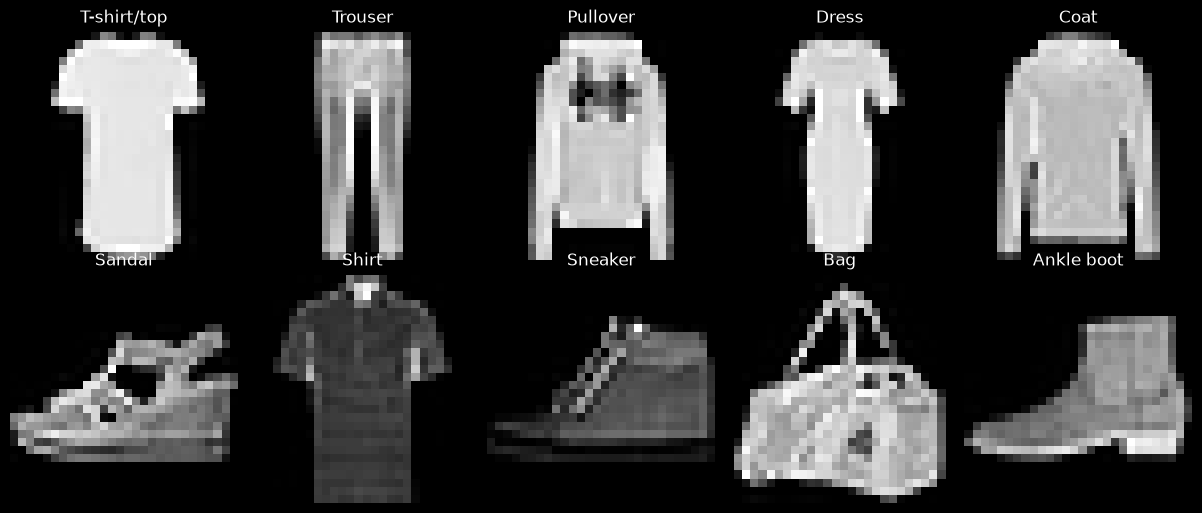

In [6]:
# Collect one representative image per class from the training set.
# We iterate through batches until we have found at least one example of each of the 10 classes.
_samples = {}
for _imgs, _lbls in train_loader:
    for _img, _lbl in zip(_imgs, _lbls):
        lbl = _lbl.item()
        if lbl not in _samples:
            # Un-normalise for display: reverse Normalize(mean, std) → pixel values in [0,1]
            _samples[lbl] = (_img.squeeze().numpy() * 0.353 + 0.286).clip(0, 1)
        if len(_samples) == 10:
            break
    if len(_samples) == 10:
        break

# Display the 10 classes in a 2×5 grid
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.patch.set_facecolor('black')
for i, ax in enumerate(axes.flat):
    ax.imshow(_samples[i], cmap='gray')
    ax.set_title(FASHION_CLASSES[i], color='white', fontsize=12, pad=7)
    ax.axis('off')
    ax.set_facecolor('black')
plt.tight_layout(pad=0.5)
plt.show()

del _samples, _imgs, _lbls, _img, _lbl  # free memory

### 1.2 — Model Architecture

The architecture you will implement:

```
Input (784)  →  Hidden 1 (256, ReLU)  →  Hidden 2 (128, ReLU)  →  Output (10 logits)
```

The `hidden_sizes` parameter controls depth — `[256, 128]` gives 2 hidden layers, `[512, 256, 128]` gives 3. This flexibility is used throughout Part 2.

Each hidden block follows this standard ordering (CM2):

```
nn.Linear  →  [nn.BatchNorm1d]  →  nn.ReLU  →  [nn.Dropout]
```

**What you need to do** (complete the `# TODO` lines in the cell below):
1. Inside the `for` loop — for each hidden layer:
   - Add a `nn.Linear` layer
   - Add `nn.BatchNorm1d` if `use_batchnorm` is True
   - Add the activation function
   - Add `nn.Dropout` if `dropout_rate > 0`
   - Update `in_dim` for the next iteration
2. After the loop — add the output projection `nn.Linear(???, ???)`

> `forward()` is already implemented — `x.view` flattens the image, then `self.net` runs the full pipeline.

In [7]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[256, 128], dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        in_dim = 784 #input layer dimension

        for h in hidden_sizes: # h is hideen layer size
            # TODO: Add linear layer. Use nn.Linear(in_features, out_features)
            layers.append(nn.Linear(in_dim,h))

            if use_batchnorm:
                # TODO: Add Batch Normalization. nn.BatchNorm1d normalises each feature independently using statistics computed across the mini-batch. How many features does the preceding Linear layer output?
                layers.append(nn.BatchNorm1d(h)) 

            # TODO: Add activation function. (CM1: what property makes it suitable for deep ReLU networks?)
            layers.append(nn.ReLU())
                          
            if dropout_rate > 0:
                # TODO: Add Dropout layer. Dropout takes a probability p in [0, 1]
                layers.append(nn.Dropout(p=dropout_rate))

            # TODO: after this block, the feature dimension has changed, update in_dim so the next iteration uses the correct input size
            in_dim = h

        # ── Output: no activation (CrossEntropyLoss handles softmax internally) ──
        # TODO: For Output layer, the input dimension is whatever came out of the last hidden block
        #                         the output dimension must match the number of classes in Fashion-MNIST
        layers.append(nn.Linear(in_dim, 10))

        # nn.Sequential wraps the layer list into a single callable module.
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten the 2D image into a 1D feature vector before passing through the layers
        x = x.view(x.size(0), -1)   # (batch, 1, 28, 28) → (batch, 784)

        # When called with self.net(x), it passes x through each layer in order. 
        # PyTorch also uses self.net to automatically track all parameters.
        logits = self.net(x)         # raw class scores — shape (batch_size, 10)
        
        return logits

In [8]:
# ── Sanity check ──────────────────────────────────────────────────────────────
# Run this cell to verify your MLP is correctly built before training.

# Instantiate the model and move it to the compute device (GPU if available)
model = MLP(hidden_sizes=[256, 128]).to(device)

# Count trainable parameters — a quick way to verify the architecture size
# For MLP([256, 128]), parameters come from 3 Linear layers:
#   784 × 256 + 256 (bias) = 200,960
#   256 × 128 + 128        =  32,896
#   128 × 10  + 10         =   1,290
#   Total                  = 235,146
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Architecture     : 784 → 256 → 128 → 10')
print(f'Total Parameters : {n_params:,}')
print(model.net)  # prints each layer in order

# Test the forward pass with a dummy batch of 4 images
# Output shape must be (batch_size, n_classes) = (4, 10)
dummy = torch.randn(4, 1, 28, 28).to(device)
out = model(dummy)
if out is not None:
    print(f'\nInput: {dummy.shape}  =>  Output: {out.shape}')  # expected: torch.Size([4, 10])
else:
    print('forward() returned None — check your TODO in forward()')

Architecture     : 784 → 256 → 128 → 10
Total Parameters : 235,146
Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)



Input: torch.Size([4, 1, 28, 28])  =>  Output: torch.Size([4, 10])


### 1.3 — Loss Function and Optimiser

Select the appropriate loss function and baseline optimiser. Each choice should be justified on the basis of the theoretical arguments from CM1 and CM2.

In [9]:
# Q1: Which loss function is correct for 10-class classification?
#     Options: nn.CrossEntropyLoss()  or  nn.MSELoss()
# Answer: CrossEntropyLoss is appropriate because the model produces 10 logits
# and each target is the integer index of the correct class. MSE is a regression loss.
criterion = nn.CrossEntropyLoss()

# Q2: Baseline optimizer — Adam with lr=1e-3, no regularisation
#     (from CM2: optim.Adam(model.parameters(), lr=..., weight_decay=...))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)

if criterion is not None and optimizer is not None:
    lr = optimizer.param_groups[0]['lr']
    wd = optimizer.param_groups[0]['weight_decay']
    print(f'Loss     : {type(criterion).__name__}')
    print(f'Optimizer: {type(optimizer).__name__}, lr={lr}, weight_decay={wd}')

Loss     : CrossEntropyLoss
Optimizer: Adam, lr=0.001, weight_decay=0.0


### 1.4 — Training Loop

The functions below implement the standard supervised training loop. Study the implementation — in particular the role of `model.train()` / `model.eval()` and `torch.no_grad()` — before executing. These functions are reused throughout Part 2.

In [10]:
def train_epoch(model, loader, criterion, optimizer):
    '''One epoch of training. Returns (avg_loss, accuracy).'''
    model.train()
    # sets training mode (only takes effect if those layers are present):
    #   - Dropout randomly zeros activations with probability p — prevents co-adaptation
    #   - BatchNorm uses batch statistics for normalisation AND accumulates running stats:
    #       batch_mean   = mean(x_batch)                           ← normalises the current batch
    #       running_mean = 0.9 * running_mean + 0.1 * batch_mean   ← updated simultaneously
    total_loss, correct, total = 0.0, 0, 0  # accumulators for the whole epoch

    for images, labels in loader:  # iterate over mini-batches
        images, labels = images.to(device), labels.to(device)  # move data to GPU/CPU

        optimizer.zero_grad()              # 1. clear gradients from the previous step (PyTorch accumulates gradients by default)
        outputs = model(images)            # 2. forward pass → logits of shape (batch, 10)
        loss = criterion(outputs, labels)  # 3. compute scalar loss for this batch
        loss.backward()                    # 4. backprop: compute dL/dw for every parameter
        optimizer.step()                   # 5. update weights: for plain SGD，it's w ← w - lr * dL/dw

        # Accumulate stats — weight by batch size because the last batch may be smaller
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)  # index of the highest logit = predicted class
        correct += predicted.eq(labels).sum().item()  # count correct predictions
        total   += images.size(0)

    return total_loss / total, correct / total  # average loss and accuracy over the epoch



def evaluate(model, loader, criterion):
    total_loss, correct, total = 0.0, 0, 0
    '''Evaluate on a data loader. Returns (avg_loss, accuracy).'''

    model.eval()
    # sets evaluation mode:
    #   - Dropout is disabled (all neurons are active, no random dropping)
    #   - BatchNorm switches from batch statistics to running statistics:
    #       During training, BatchNorm computes mean/var from each batch AND
    #       accumulates a running_mean/running_var via exponential moving average.
    #       During eval, it uses these accumulated values instead of the current batch —
    #       more stable, especially when batch_size is small or equals 1.

    with torch.no_grad():  # disable gradient computation — faster and uses less memory
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)  # move data to GPU/CPU
            outputs = model(images)            # forward pass — no gradient tracked
            loss = criterion(outputs, labels)  # compute loss for this batch

            # Same accumulation logic as train_epoch
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)  # predicted class = index of highest logit
            correct += predicted.eq(labels).sum().item()
            total   += images.size(0)

    return total_loss / total, correct / total

In [11]:
# ── Train your baseline model ─────────────────────────────────────────────────
NUM_EPOCHS = 15
baseline_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Epoch | Train Loss |  Val Loss | Train Acc |  Val Acc')
print('-' * 54)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    baseline_history['train_loss'].append(tr_loss)
    baseline_history['val_loss'].append(va_loss)
    baseline_history['train_acc'].append(tr_acc)
    baseline_history['val_acc'].append(va_acc)

    print(f'{epoch:>5} | {tr_loss:>10.4f} | {va_loss:>8.4f} | {tr_acc:>9.2%} | {va_acc:>7.2%}')

test_loss, test_acc = evaluate(model, test_loader, criterion)
print()
print(f'Baseline Test Accuracy: {test_acc:.2%}')

Epoch | Train Loss |  Val Loss | Train Acc |  Val Acc
------------------------------------------------------


    1 |     0.4785 |   0.4061 |    82.60% |  84.82%


    2 |     0.3542 |   0.3538 |    86.91% |  87.44%


    3 |     0.3156 |   0.3314 |    88.40% |  87.92%


    4 |     0.2895 |   0.3267 |    89.31% |  88.24%


...

   12 |     0.1817 |   0.3388 |    93.09% |  88.92%


   13 |     0.1685 |   0.3644 |    93.55% |  88.58%


   14 |     0.1632 |   0.3622 |    93.78% |  89.02%


   15 |     0.1565 |   0.3597 |    93.95% |  89.08%



Baseline Test Accuracy: 88.69%


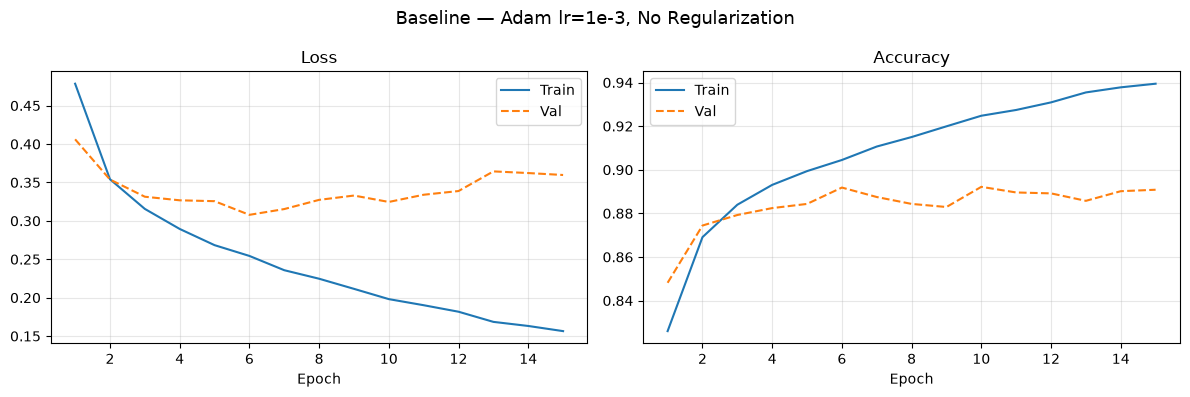

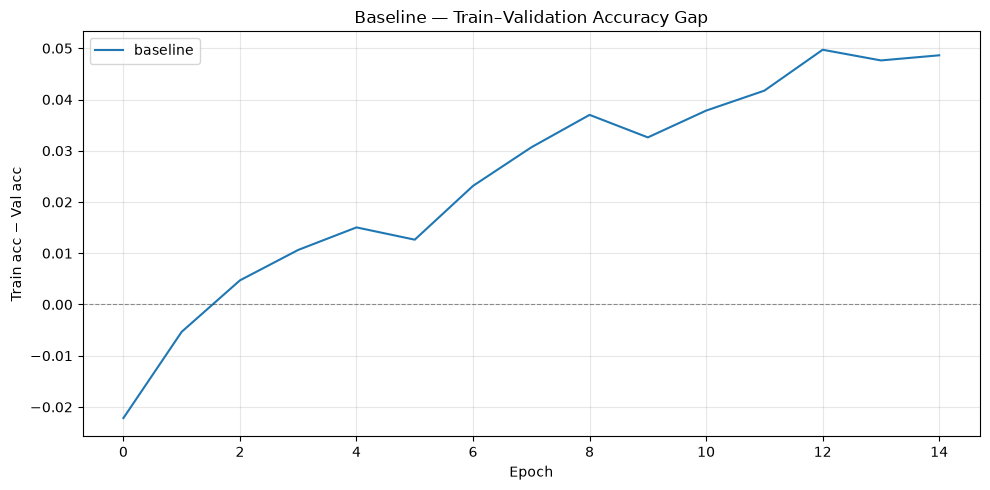

In [12]:
def plot_history(history, title='Training Curves'):
    '''Plot loss and accuracy curves from a history dict.'''
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val', linestyle='--')
    ax1.set_title('Loss');     ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train')
    ax2.plot(epochs, history['val_acc'],   label='Val', linestyle='--')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

def plot_gap(results, title='Train–Validation Accuracy Gap'):
    '''
    Plot the train-val accuracy gap (train_acc - val_acc) per epoch.
    '''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        gap = [t - v for t, v in zip(hist['train_acc'], hist['val_acc'])]
        plt.plot(gap, label=label)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)  # zero-gap reference line
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Train acc − Val acc')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
plot_history(baseline_history, title='Baseline — Adam lr=1e-3, No Regularization')
plot_gap({'baseline': baseline_history}, title='Baseline — Train–Validation Accuracy Gap')

**Section 1 of your report** is based on what you just built and observed. Before moving on to Part 2, document:

- **Architecture**: layer dimensions and total parameter count
- **Loss function**: which one you chose and why it is appropriate for this task
- **Training configuration**: optimiser and key hyperparameters
- **Baseline results**: analyse the training curves — what does the train–validation accuracy gap tell you? (*Hint: compute the gap at the final epoch. A large or increasing train–validation gap can indicate overfitting.*)

---
## Part 2 — Experimental Analysis

This section guides you through the typical workflow of solving a supervised learning problem:

1. **Experiment 1 — Architecture**: find a model with sufficient capacity
2. **Experiment 2 — Optimiser & LR**: tune the training process for that model
3. **Experiment 3 — Regularisation**: address the overfitting observed in Experiment 1

**Protocol for each experiment:**
1. Read the experiment description carefully *before* running any code.
2. Complete the provided scaffold and run the experiment.
3. Generate the required comparison figures.
4. Fill in the **Results and Analysis** section with your observations and answers.

> **Implementation note**: `run_experiment()` instantiates and trains a freshly initialised model for each call. Because training is stochastic, numerical results may vary slightly between runs.

> **Pedagogical note**: Test accuracy is displayed in this TP for comparison and illustration. However, architecture and hyperparameter choices must be based on validation performance only. In a standard machine-learning workflow, the test set should be reserved for the final evaluation.

In [13]:
# ── Helper functions (provided — read before using) ───────────────────────────

def run_experiment(
    hidden_sizes=[256, 128], 
    dropout_rate=0.0,
    use_batchnorm=False,
    optimizer='adam',    # 'adam' or 'sgd'
    lr=1e-3,
    weight_decay=0.0,
    momentum=0.0,        # for SGD with momentum only
    num_epochs=15,
    tag='',
    seed=42
):
    '''
    Train a fresh MLP and return its history + test accuracy.

    Args:
        hidden_sizes  : list of hidden layer widths, e.g. [256, 128]
        dropout_rate  : Dropout probability (0 = disabled)
        use_batchnorm : whether to insert BatchNorm1d after each Linear
        optimizer     : 'adam' or 'sgd'
        lr            : learning rate
        weight_decay  : L2 regularisation coefficient
        momentum      : SGD momentum (ignored for Adam)
        num_epochs    : number of training epochs
        tag           : label printed in the console
        seed          : random seed used for reproducible comparisons

    Returns:
        hist     : dict with train_loss / val_loss / train_acc / val_acc (one value per epoch)
        test_acc : final accuracy on the held-out test set
    '''
    # Reset randomness so comparable runs start from reproducible conditions.
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Create a fresh, untrained model for this experiment
    model = MLP(hidden_sizes=hidden_sizes,
                dropout_rate=dropout_rate,
                use_batchnorm=use_batchnorm).to(device)

    # Create the optimiser
    if optimizer == 'adam':
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer == 'sgd':
        opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        raise ValueError(f"optimizer must be 'adam' or 'sgd', got {optimizer!r}")

    crit = nn.CrossEntropyLoss()
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print()
    print('-' * 50)
    print(f'  {tag}')
    print('-' * 50)

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, crit, opt)
        va_loss, va_acc = evaluate(model, val_loader, crit)
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(va_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(va_acc)
        print(f'  Epoch {epoch:>2}: train={tr_acc:.2%}  val={va_acc:.2%}')

    _, test_acc = evaluate(model, test_loader, crit)
    print(f'  Test accuracy: {test_acc:.2%}')
    return hist, test_acc


def plot_comparison(results, metric='val_acc', title='Comparison'):
    '''Overlay multiple experiment runs on one plot.'''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        plt.plot(hist[metric], label=label)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_gap(results, title='Train–Validation Accuracy Gap'):
    '''
    Plot the train-val accuracy gap (train_acc - val_acc) per epoch.
    '''
    plt.figure(figsize=(10, 5))
    for label, hist in results.items():
        gap = [t - v for t, v in zip(hist['train_acc'], hist['val_acc'])]
        plt.plot(gap, label=label)
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Train acc − Val acc')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Experiment 1 — Model Architecture
**Objective**: Identify how model capacity affects learning — both in terms of final generalisation performance and convergence speed. In practice, architecture selection comes first: a model that is too small cannot learn the task (**underfitting**), while one that is too large memorises training-specific patterns (**overfitting**). The goal is to find the capacity sweet spot.

**Setting**: Adam `lr=1e-3`, no regularisation, **15 epochs**. Vary `hidden_sizes`:

| Config | hidden_sizes | Approx. params |
|--------|-------------|----------------|
| Micro | `[4]` | ~3k |
| Small | `[64]` | ~51k |
| Baseline | `[256, 128]` | ~235k |
| Large | `[512, 256]` | ~537k |

**What to observe**:
1. **`plot_gap`**: does the train–validation accuracy gap grow monotonically with the increase of model size?
2. **`plot_comparison(train_acc)`**: does a larger model converge faster in early epochs?
3. **`plot_comparison(val_acc)`**: where does val accuracy plateau — and what does that tell you about the benefit of adding more model capacity?



--------------------------------------------------
  Micro [4]
--------------------------------------------------


  Epoch  1: train=59.34%  val=67.42%


  Epoch  2: train=72.47%  val=74.56%


  Epoch  3: train=77.90%  val=78.94%


  Epoch  4: train=80.18%  val=80.12%


...

  Epoch 12: train=93.50%  val=88.96%


  Epoch 13: train=93.90%  val=89.21%


  Epoch 14: train=94.12%  val=89.18%


  Epoch 15: train=94.36%  val=88.74%


  Test accuracy: 88.58%

Final summary (epoch 15)
Configuration           Train      Val      Gap     Test
Micro [4]               83.16%   82.52%    0.64%   81.90%
Small [64]              92.01%   88.66%    3.35%   88.28%
Baseline [256, 128]     94.18%   89.02%    5.17%   88.47%
Large [512, 256]        94.36%   88.74%    5.62%   88.58%


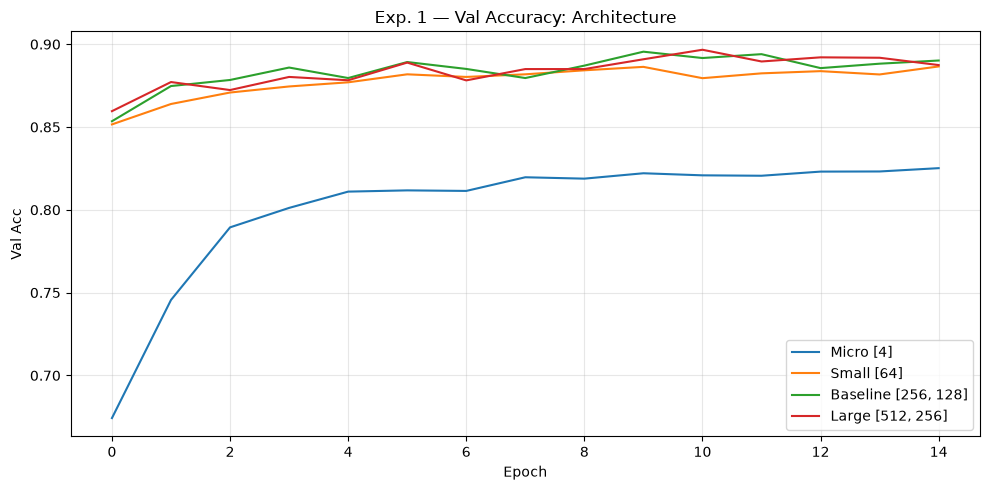

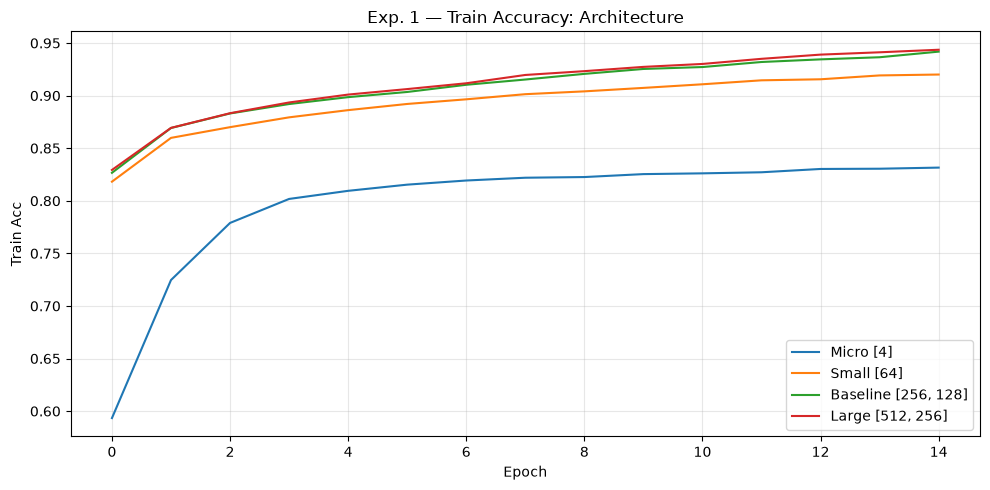

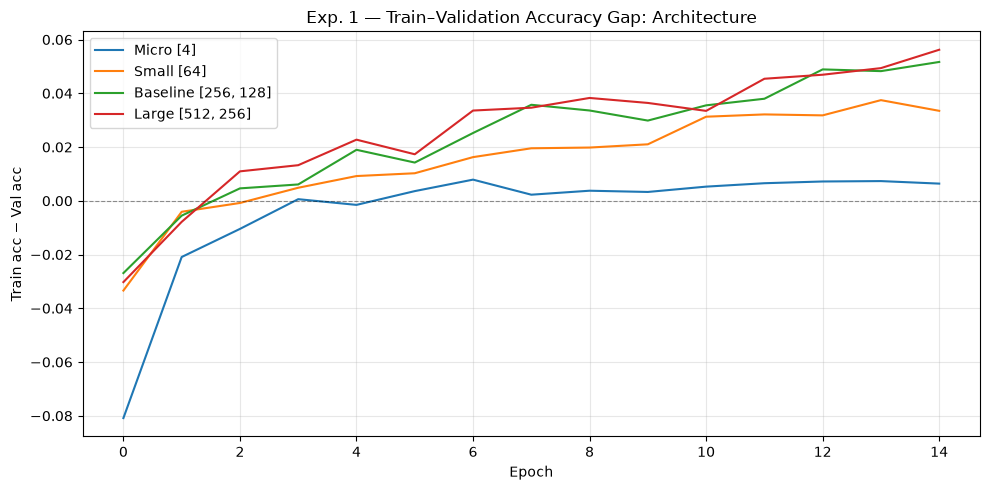

In [14]:
# ── Experiment 1  Model Architecture ─────────────────────────────────────────
exp_1 = {}
exp_1_test_acc = {}

# Controlled experiment: only the hidden-layer sizes change.
architectures = {
    'Micro [4]': [4],
    'Small [64]': [64],
    'Baseline [256, 128]': [256, 128],
    'Large [512, 256]': [512, 256],
}

for label, hidden_sizes in architectures.items():
    hist, test_acc = run_experiment(
        hidden_sizes=hidden_sizes,
        optimizer='adam',
        lr=1e-3,
        num_epochs=15,
        tag=label
    )
    exp_1[label] = hist
    exp_1_test_acc[label] = test_acc

print('\nFinal summary (epoch 15)')
print('Configuration           Train      Val      Gap     Test')
for label, hist in exp_1.items():
    train_acc = hist['train_acc'][-1]
    val_acc = hist['val_acc'][-1]
    gap = train_acc - val_acc
    print(f'{label:<22} {train_acc:>7.2%}  {val_acc:>7.2%}  {gap:>7.2%}  {exp_1_test_acc[label]:>7.2%}')

plot_comparison(exp_1, metric='val_acc',   title='Exp. 1 — Val Accuracy: Architecture')
plot_comparison(exp_1, metric='train_acc', title='Exp. 1 — Train Accuracy: Architecture')
plot_gap(exp_1, title='Exp. 1 — Train–Validation Accuracy Gap: Architecture')

**Results and Analysis**

| Config | Train acc (ep15) | Val acc (ep15) | Gap | Test acc |
|--------|-----------------:|---------------:|----:|---------:|
| Micro [4] | 83.16% | 82.52% | 0.64% | 81.90% |
| Small [64] | 92.01% | 88.66% | 3.35% | 88.28% |
| Baseline [256, 128] | 94.18% | **89.02%** | 5.17% | 88.47% |
| Large [512, 256] | 94.36% | 88.74% | 5.62% | **88.58%** |

> Results obtained with seed 42. Small differences may remain across GPU runs.

- **Underfitting.** Micro ends at 83.16% training accuracy and 82.52% validation accuracy. Its 0.64-point gap is small because the model lacks capacity. It cannot fit the training set well enough to perform better on validation data.
- **Overfitting.** Small ends with a 3.35-point gap. Baseline and Large exceed 5 points. Their training accuracy keeps rising after validation accuracy reaches a plateau. Large peaks at 89.67% validation accuracy in epoch 11, then falls to 88.74%.
- **Validation plateau.** Moving from Micro to Small adds 6.14 points of validation accuracy at epoch 15. Baseline adds only 0.36 points, and Large finishes slightly below it. The extra capacity mainly improves the fit to the training set.
- **Bias-variance trade-off.** The final gap grows with capacity: 0.64%, 3.35%, 5.17%, and 5.62%. Micro has high bias. Larger models reduce bias but become more sensitive to patterns specific to the training set.
- **Selection.** I selected **Baseline [256, 128]**. Its best validation accuracy is 89.55%, and its final validation accuracy exceeds Large. Large gains only 0.12 points at its peak, uses about twice as many parameters, and ends with a larger gap.

### Experiment 2 — Optimiser and Learning Rate

Having selected an architecture in Experiment 1, the next step is to ensure training is efficient.

This experiment is split into two connected sub-experiments:

| Sub-experiment | Objective |
|----------------|-----------|
| **2.A — Learning rate** | Show that SGD is highly sensitive to LR — motivating the need for adaptive optimisers |
| **2.B — Optimiser comparison** | Verify that Adam addresses SGD's LR sensitivity and converges faster |

#### 2.A — Learning Rate

**Objective**: Demonstrate that SGD's performance depends critically on learning rate — and why this is a problem in practice.

**Setting**: architecture `[256, 128]`, SGD (no momentum), no regularisation, 15 epochs.  
**Vary**: LR ∈ {1e-5, 1e-3, 0.1}

| LR | Expected behaviour |
|----|--------------------|
| `1e-5` | Near-random accuracy — updates too small to move weights meaningfully |
| `1e-3` | Slow convergence — learning, but far from optimal within 15 epochs |
| `0.1` | Near-optimal — fast, stable convergence |


--------------------------------------------------
  SGD lr=1e-05
--------------------------------------------------


  Epoch  1: train=9.71%  val=9.95%


  Epoch  2: train=9.87%  val=10.16%


  Epoch  3: train=10.12%  val=10.38%


  Epoch  4: train=10.30%  val=10.60%


...

  Epoch 12: train=92.68%  val=89.43%


  Epoch 13: train=93.02%  val=89.08%


  Epoch 14: train=93.36%  val=87.53%


  Epoch 15: train=93.69%  val=88.64%


  Test accuracy: 87.85%


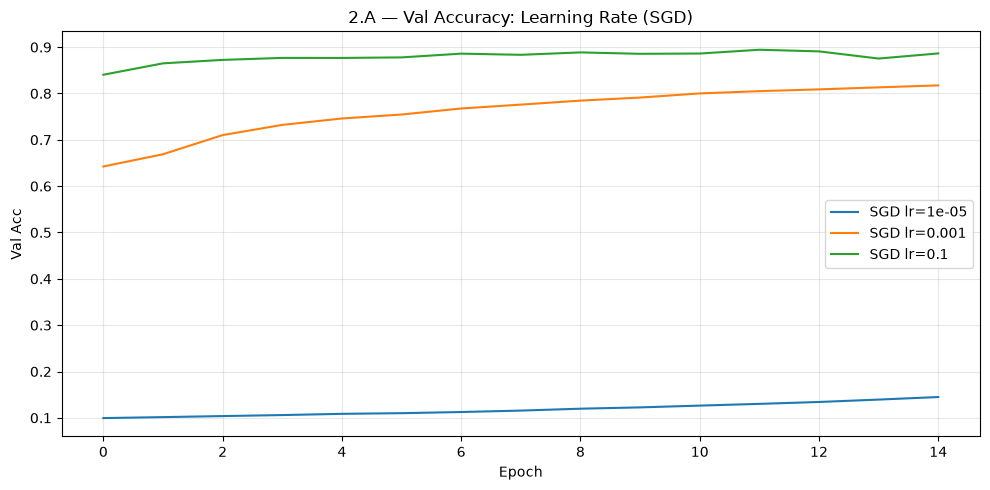

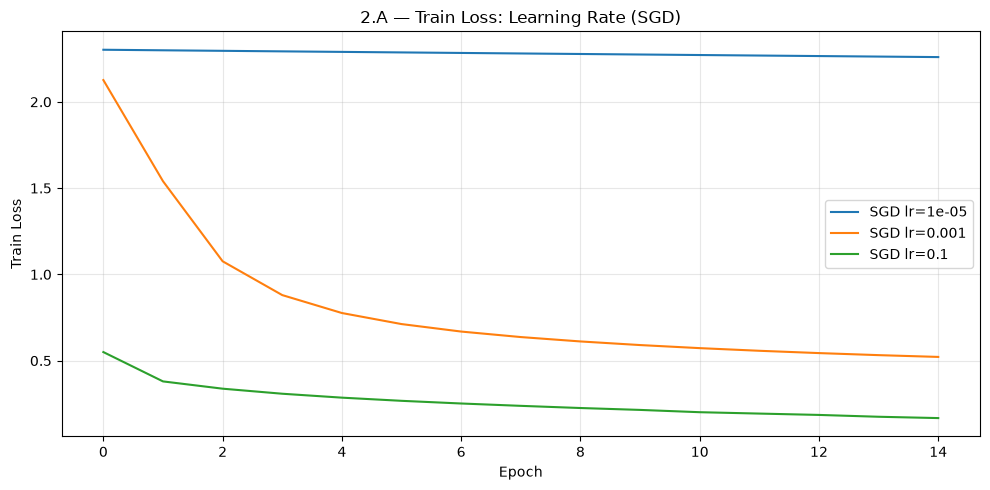

In [15]:
# ── 2.A  Learning Rate ────────────────────────────────────────────────────────
exp_2a = {}
exp_2a_test_acc = {}

for lr in [1e-5, 1e-3, 0.1]:
    label = f'SGD lr={lr:g}'
    hist, test_acc = run_experiment(
        hidden_sizes=[256, 128],
        optimizer='sgd',
        lr=lr,
        num_epochs=15,
        tag=label
    )
    exp_2a[label] = hist
    exp_2a_test_acc[label] = test_acc

plot_comparison(exp_2a, metric='val_acc',    title='2.A — Val Accuracy: Learning Rate (SGD)')
plot_comparison(exp_2a, metric='train_loss', title='2.A — Train Loss: Learning Rate (SGD)')

**Results and Analysis**

| SGD learning rate | Val acc (ep15) | Best val acc | Test acc |
|------------------:|---------------:|-------------:|---------:|
| `1e-5` | 14.49% | 14.49% | 14.40% |
| `1e-3` | 81.74% | 81.74% | 80.65% |
| `0.1` | 88.64% | **89.43%** | **87.85%** |

At `1e-5`, the updates are too small. After 15 epochs, validation accuracy reaches only 14.49%, barely above the 10% random baseline for ten classes. The model learns at `1e-3`, but slowly: it takes 11 epochs to exceed 80% and finishes at 81.74%.

At `0.1`, SGD exceeds 80% in the first epoch, 85% in the second, and 88% in the seventh. It reaches its best score, 89.43%, in epoch 12. A poor learning rate therefore costs several epochs and may prevent the model from finding a good solution within the training budget.

#### 2.B — Optimiser Comparison

**Objective**: Compare the convergence speed of SGD and Adam across the same range of learning rates — and determine whether Adam's adaptive mechanism provides a meaningful advantage.

**Setting**: architecture `[256, 128]`, no regularisation, **15 epochs**.

| Configuration | Optimiser | LR |
|---------------|-----------|-----|
| SGD — naive | SGD | `1e-3` |
| SGD — tuned | SGD | `0.1` |
| Adam — naive | Adam | `1e-3` |
| Adam lr=0.1 | Adam | `0.1` |
| Adam lr=1e-5 | Adam | `1e-5` |

**Focus on convergence speed** — how many epochs does each configuration need to reach 80%? 85%? 88% val accuracy?


--------------------------------------------------
  Adam lr=0.001
--------------------------------------------------


  Epoch  1: train=82.66%  val=85.35%


  Epoch  2: train=86.92%  val=87.48%


  Epoch  3: train=88.30%  val=87.84%


  Epoch  4: train=89.20%  val=88.59%


...

  Epoch 12: train=84.61%  val=84.11%


  Epoch 13: train=84.81%  val=84.21%


  Epoch 14: train=85.02%  val=84.67%


  Epoch 15: train=85.21%  val=84.64%


  Test accuracy: 83.66%


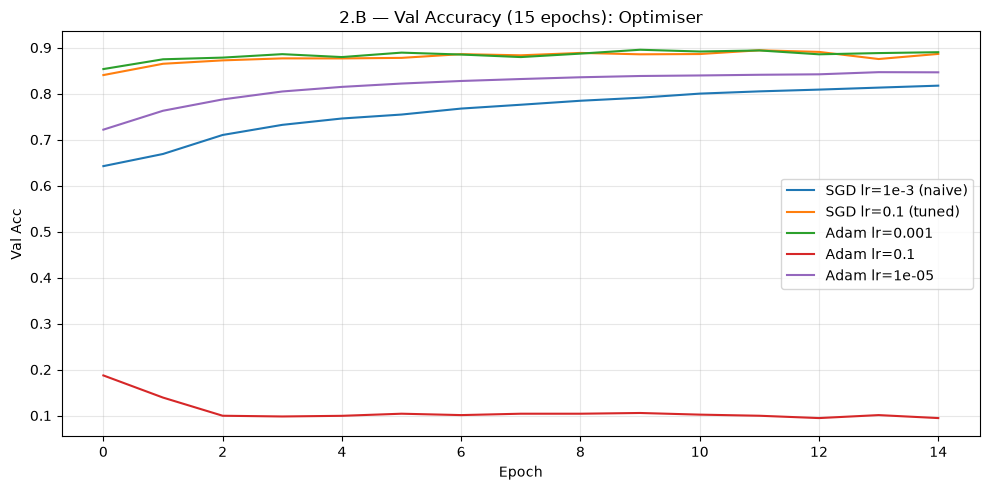

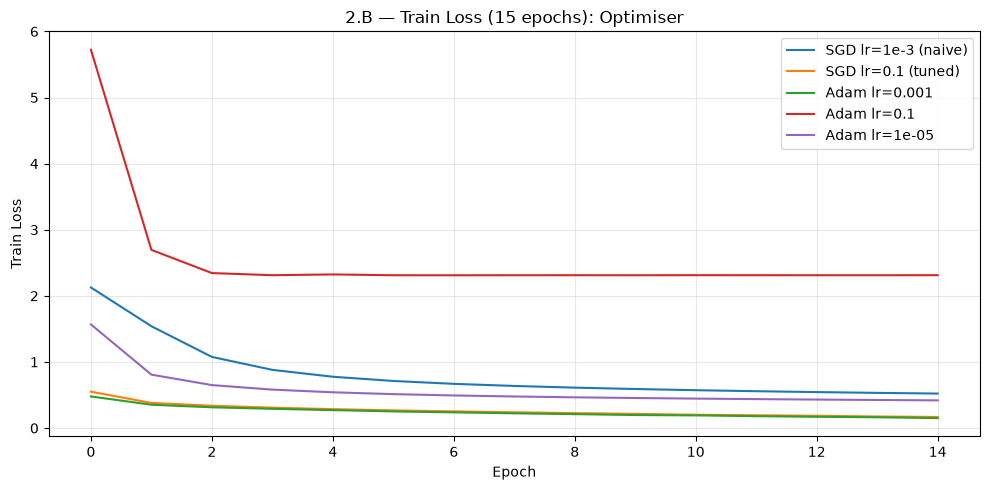

In [16]:
# ── 2.B  Optimiser Comparison ─────────────────────────────────────────────────
# Compare SGD and Adam across the same LR values to show Adam's robustness
# Reuse the two SGD runs from 2.A, then train the three Adam configurations.
exp_2b = {
    'SGD lr=1e-3 (naive)': exp_2a['SGD lr=0.001'],
    'SGD lr=0.1 (tuned)': exp_2a['SGD lr=0.1'],
}
exp_2b_test_acc = {
    'SGD lr=1e-3 (naive)': exp_2a_test_acc['SGD lr=0.001'],
    'SGD lr=0.1 (tuned)': exp_2a_test_acc['SGD lr=0.1'],
}

for lr in [1e-3, 0.1, 1e-5]:
    label = f'Adam lr={lr:g}'
    hist, test_acc = run_experiment(
        hidden_sizes=[256, 128],
        optimizer='adam',
        lr=lr,
        num_epochs=15,
        tag=label
    )
    exp_2b[label] = hist
    exp_2b_test_acc[label] = test_acc

plot_comparison(exp_2b, metric='val_acc',    title='2.B — Val Accuracy (15 epochs): Optimiser')
plot_comparison(exp_2b, metric='train_loss', title='2.B — Train Loss (15 epochs): Optimiser')

**Results and Analysis**

| Configuration | Learning rate | Best val acc | Epoch of best | Epochs to 80% / 85% / 88% |
|---------------|--------------:|-------------:|--------------:|--------------------------:|
| SGD best | `0.1` | 89.43% | 12 | 1 / 2 / 7 |
| Adam best | `1e-3` | **89.55%** | 10 | 1 / 1 / 4 |

Adam performs best at `1e-3`, while SGD needs `0.1`. At their best tested learning rates, Adam reaches 85% and 88% sooner. Its estimates of the first and second gradient moments adjust the update for each parameter, which speeds up the early epochs in this experiment.

At the same learning rate (`1e-3`), Adam finishes at 89.02% validation accuracy, compared with 81.74% for SGD. The same value therefore behaves differently across optimisers. Adam still needs a sensible setting: at `0.1` it collapses to 9.45%, while `1e-5` is too slow and finishes at 84.64%.


### Experiment 3 — Regularisation

**Objective**: In Experiment 1 you observed that `[256, 128]` shows a train–validation accuracy gap of ~4–5%. This experiment investigates techniques to reduce that gap without sacrificing validation accuracy.

**Setting**: architecture `[256, 128]`, Adam `lr=1e-3`, **20 epochs** (longer run makes overfitting dynamics clearly visible).

| Configuration | Parameters |
|---------------|-----------|
| Baseline | `dropout_rate=0.0, use_batchnorm=False` |
| Dropout | `dropout_rate=0.3` |
| Weight decay | `weight_decay=1e-3` in Adam |
| Dropout + BN | both enabled |

Plot `val_acc`, `train_acc`, and **`plot_gap`** — the gap plot directly shows which technique reduces overfitting most effectively.

> **Reminder**: A widening train–validation gap can indicate overfitting. Another common sign is that training performance continues to improve while validation performance stagnates or deteriorates.


--------------------------------------------------
  No regularisation
--------------------------------------------------


  Epoch  1: train=82.66%  val=85.35%


  Epoch  2: train=86.92%  val=87.48%


  Epoch  3: train=88.30%  val=87.84%


  Epoch  4: train=89.20%  val=88.59%


...

  Epoch 17: train=91.09%  val=89.08%


  Epoch 18: train=91.13%  val=89.70%


  Epoch 19: train=91.39%  val=89.70%


  Epoch 20: train=91.55%  val=89.33%


  Test accuracy: 88.93%


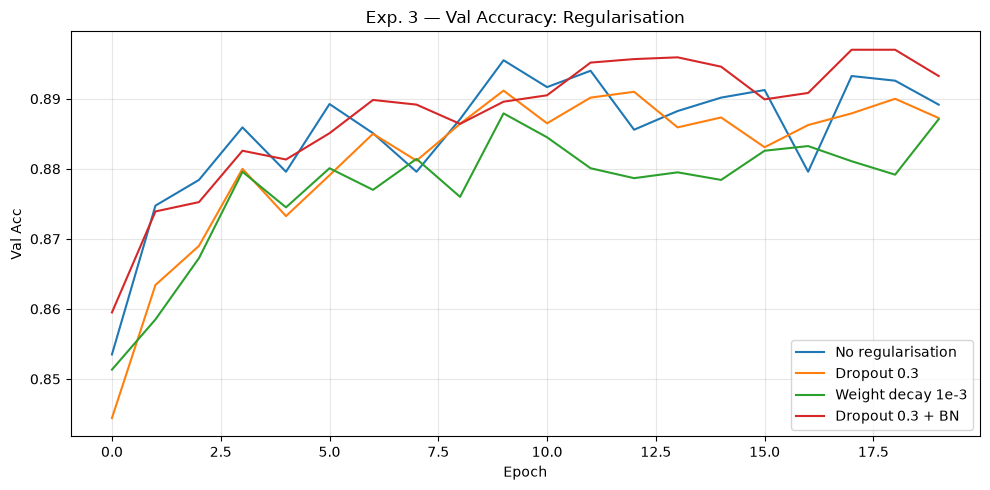

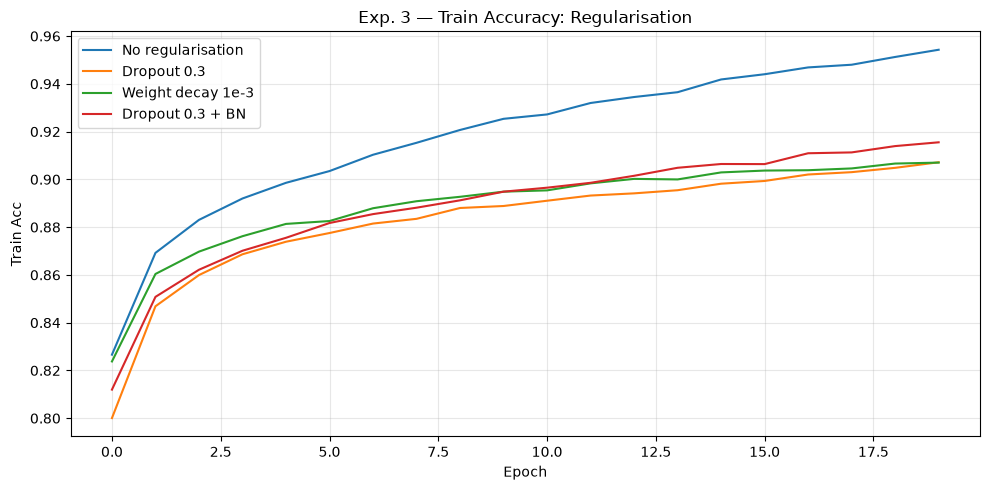

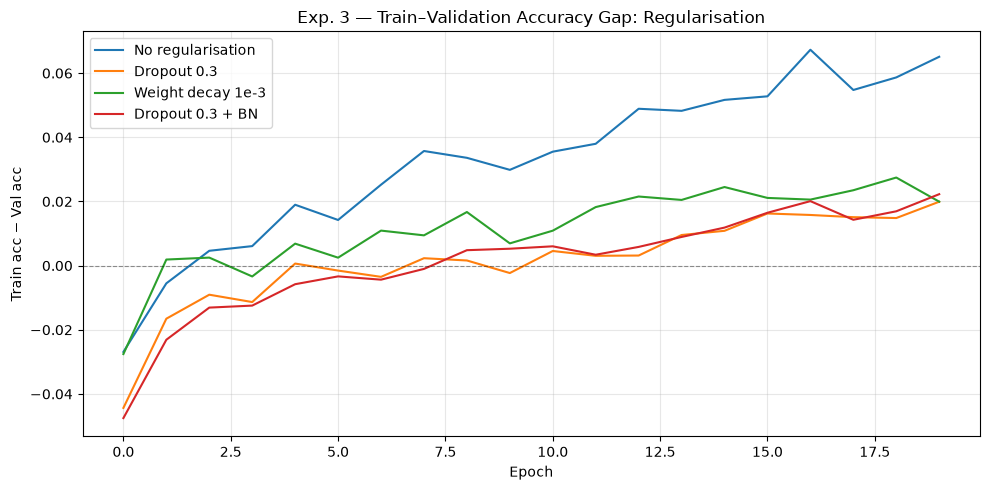

In [17]:
# ── Experiment 3  Regularisation ─────────────────────────────────────────────
exp_3 = {}
N_EPOCHS = 20

exp_3_test_acc = {}
regularisation_configs = {
    'No regularisation': {},
    'Dropout 0.3': {'dropout_rate': 0.3},
    'Weight decay 1e-3': {'weight_decay': 1e-3},
    'Dropout 0.3 + BN': {'dropout_rate': 0.3, 'use_batchnorm': True},
}

for label, extra_args in regularisation_configs.items():
    hist, test_acc = run_experiment(
        hidden_sizes=[256, 128],
        optimizer='adam',
        lr=1e-3,
        num_epochs=N_EPOCHS,
        tag=label,
        **extra_args
    )
    exp_3[label] = hist
    exp_3_test_acc[label] = test_acc

plot_comparison(exp_3, metric='val_acc',   title='Exp. 3 — Val Accuracy: Regularisation')
plot_comparison(exp_3, metric='train_acc', title='Exp. 3 — Train Accuracy: Regularisation')
plot_gap(exp_3, title='Exp. 3 — Train–Validation Accuracy Gap: Regularisation')

**Results and Analysis**

| Configuration | Train (ep20) | Val (ep20) | Gap | Test acc | Best val epoch |
|---------------|-------------:|-----------:|----:|---------:|---------------:|
| No regularisation | 95.43% | 88.92% | 6.51% | 88.81% | 10 |
| Dropout 0.3 | 90.72% | 88.73% | **1.99%** | 88.48% | 10 |
| Weight decay 1e-3 | 90.70% | 88.71% | 1.99% | 88.27% | 10 |
| Dropout 0.3 + BN | 91.55% | **89.33%** | 2.23% | **88.93%** | 18 |

Without regularisation, training accuracy reaches 95.43% while validation accuracy finishes at 88.92%. The gap is 6.51 points. Dropout randomly removes activations during training, which limits co-adaptation between neurons. Weight decay penalises large weights and limits the complexity of the learned function. Both methods reduce the gap to about 1.99 points.

Dropout alone gives the smallest gap, although the difference from weight decay is only 0.002 points. Dropout with BatchNorm gives the best final validation accuracy (89.33%), peak validation accuracy (89.70%), and test accuracy (88.93%). It peaks in epoch 18, compared with epoch 10 for the other three configurations. Here, regularisation slows the fit to the training set but allows validation performance to improve for longer.